In [182]:
import sys
import os 
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

sys.path.append(os.path.abspath("../../"))
sys.path.append(os.path.abspath("../3_Helpers"))
from optimizer import variables

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

2. Load / copy data

In [183]:
df = pd.read_csv("Optimization_data/optimization_results_bess_pv_price_100.csv").iloc[:,:4]
df = df.copy()
display(df[:4])

,price_col,gen_scenario,bess_duration_h,sum_actual_revenue_row_total
0,Year 1,0,2.0,9.202863e+05
1,Year 1,0,2.5,1.038572e+06
2,Year 1,0,3.0,1.106216e+06
3,Year 1,0,3.5,1.165870e+06


3. Compute percentile per scenario + BESS

In [184]:
df["P"] = (
    df.groupby(["gen_scenario","bess_duration_h"])["sum_actual_revenue_row_total"]
    .rank(method="first", pct=True, ascending=False)
)

df["P"] *= 100
df["P_bin"] = df["P"].round().astype(int)
display(df[:4])

,price_col,gen_scenario,bess_duration_h,sum_actual_revenue_row_total,P,P_bin
0,Year 1,0,2.0,9.202863e+05,1.0,1
1,Year 1,0,2.5,1.038572e+06,1.0,1
2,Year 1,0,3.0,1.106216e+06,1.0,1
3,Year 1,0,3.5,1.165870e+06,1.0,1


In [185]:
df.groupby("gen_scenario")["bess_duration_h"].nunique()

gen_scenario
0    13
1    13
2    13
3    13
4    13
5    13
6    13
7    13
Name: bess_duration_h, dtype: int64

4. Pivot into curve matrix

In [186]:
curve_df = df.pivot_table(
    index=["gen_scenario","bess_duration_h"],
    columns="P_bin",
    values="sum_actual_revenue_row_total",
    aggfunc="mean"
).sort_index(axis=1)
display(curve_df[:4])

P_bin                                  1             2             3    \
gen_scenario bess_duration_h                                             
0            2.0              9.202863e+05  9.075185e+05  8.385210e+05   
             2.5              1.038572e+06  1.011909e+06  9.540104e+05   
             3.0              1.106216e+06  1.060895e+06  1.020882e+06   
             3.5              1.165870e+06  1.105423e+06  1.081904e+06   

P_bin                                  4             5             6    \
gen_scenario bess_duration_h                                             
0            2.0              8.365285e+05  8.276248e+05  8.103435e+05   
             2.5              9.438247e+05  9.219706e+05  9.179934e+05   
             3.0              1.013792e+06  9.927208e+05  9.659398e+05   
             3.5              1.076846e+06  1.062022e+06  1.033411e+06   

P_bin                                  7            8            9    \
gen_scenario bess_duration_h                                           
0            2.0              8.041789e+05  757640.6981  739855.3965   
             2.5              8.862702e+05  874814.6488  840580.2628   
             3.0              9.564743e+05  923098.5559  905674.8962   
             3.5              1.005459e+06  966143.4458  955654.8620   

P_bin                                 10           11           12   \
gen_scenario bess_duration_h                                          
0            2.0              695795.7142  692533.7299  661965.3511   
             2.5              793361.8357  788235.1517  748240.1341   
             3.0              852281.4474  847637.2980  806648.7144   
             3.5              909191.4057  895992.4185  862489.9416   

P_bin                                 13           14           15   \
gen_scenario bess_duration_h                                          
0            2.0              657721.3438  647468.0429  642790.2043   
             2.5              734492.7963  732421.3587  727735.8315   
             3.0              787163.5202  785373.5272  778692.8227   
             3.5              838266.9263  831528.1363  827989.1657   

P_bin                                 16           17           18   \
gen_scenario bess_duration_h                                          
0            2.0              635618.6857  625196.7770  594282.4928   
             2.5              725448.8163  697546.9443  666905.7483   
             3.0              776412.0626  740537.9324  718577.7911   
             3.5              814106.4529  778043.3078  773810.6497   

P_bin                                 19           20           21   \
gen_scenario bess_duration_h                                          
0            2.0              578953.3855  571891.6403  568497.9706   
             2.5              657612.1759  631468.7643  623760.1534   
             3.0              714193.5823  659018.5982  650306.6104   
             3.5              754022.6409  688449.7059  683687.3026   

P_bin                                 22           23           24   \
gen_scenario bess_duration_h                                          
0            2.0              560261.5431  522299.8173  520850.7111   
             2.5              615009.4775  596188.3646  584056.0295   
             3.0              645483.8464  642797.3180  624146.9291   
             3.5              673723.5911  667148.3343  663284.5448   

P_bin                                 25           26           27   \
gen_scenario bess_duration_h                                          
0            2.0              520552.0867  520368.8854  509476.1394   
             2.5              578194.2714  574136.0129  570454.3056   
             3.0              623971.1617  617415.5285  615531.6175   
             3.5              660806.5254  660070.0258  657990.7420   

P_bin                                 28           29           30   \
gen_scenario bess_duration_h                

5. Handle missing values (important)

In [187]:
curve_df = curve_df.interpolate(axis=1).ffill(axis=1).bfill(axis=1)
display(curve_df[:4])

P_bin                                  1             2             3    \
gen_scenario bess_duration_h                                             
0            2.0              9.202863e+05  9.075185e+05  8.385210e+05   
             2.5              1.038572e+06  1.011909e+06  9.540104e+05   
             3.0              1.106216e+06  1.060895e+06  1.020882e+06   
             3.5              1.165870e+06  1.105423e+06  1.081904e+06   

P_bin                                  4             5             6    \
gen_scenario bess_duration_h                                             
0            2.0              8.365285e+05  8.276248e+05  8.103435e+05   
             2.5              9.438247e+05  9.219706e+05  9.179934e+05   
             3.0              1.013792e+06  9.927208e+05  9.659398e+05   
             3.5              1.076846e+06  1.062022e+06  1.033411e+06   

P_bin                                  7            8            9    \
gen_scenario bess_duration_h                                           
0            2.0              8.041789e+05  757640.6981  739855.3965   
             2.5              8.862702e+05  874814.6488  840580.2628   
             3.0              9.564743e+05  923098.5559  905674.8962   
             3.5              1.005459e+06  966143.4458  955654.8620   

P_bin                                 10           11           12   \
gen_scenario bess_duration_h                                          
0            2.0              695795.7142  692533.7299  661965.3511   
             2.5              793361.8357  788235.1517  748240.1341   
             3.0              852281.4474  847637.2980  806648.7144   
             3.5              909191.4057  895992.4185  862489.9416   

P_bin                                 13           14           15   \
gen_scenario bess_duration_h                                          
0            2.0              657721.3438  647468.0429  642790.2043   
             2.5              734492.7963  732421.3587  727735.8315   
             3.0              787163.5202  785373.5272  778692.8227   
             3.5              838266.9263  831528.1363  827989.1657   

P_bin                                 16           17           18   \
gen_scenario bess_duration_h                                          
0            2.0              635618.6857  625196.7770  594282.4928   
             2.5              725448.8163  697546.9443  666905.7483   
             3.0              776412.0626  740537.9324  718577.7911   
             3.5              814106.4529  778043.3078  773810.6497   

P_bin                                 19           20           21   \
gen_scenario bess_duration_h                                          
0            2.0              578953.3855  571891.6403  568497.9706   
             2.5              657612.1759  631468.7643  623760.1534   
             3.0              714193.5823  659018.5982  650306.6104   
             3.5              754022.6409  688449.7059  683687.3026   

P_bin                                 22           23           24   \
gen_scenario bess_duration_h                                          
0            2.0              560261.5431  522299.8173  520850.7111   
             2.5              615009.4775  596188.3646  584056.0295   
             3.0              645483.8464  642797.3180  624146.9291   
             3.5              673723.5911  667148.3343  663284.5448   

P_bin                                 25           26           27   \
gen_scenario bess_duration_h                                          
0            2.0              520552.0867  520368.8854  509476.1394   
             2.5              578194.2714  574136.0129  570454.3056   
             3.0              623971.1617  617415.5285  615531.6175   
             3.5              660806.5254  660070.0258  657990.7420   

P_bin                                 28           29           30   \
gen_scenario bess_duration_h                

6. PCA decomposition

In [188]:
X = curve_df.values

pca = PCA(n_components=3)
trained_PCA_model = pca.fit_transform(X)

print("Explained variance:", pca.explained_variance_ratio_)

Explained variance: [9.95861428e-01 3.44896595e-03 2.00950890e-04]


7. Build coefficient dataframe (FIXED)

In [189]:
coef_df = pd.DataFrame(trained_PCA_model, columns=["PC1","PC2","PC3"])
coef_df["gen_scenario"] = curve_df.index.get_level_values(0)
coef_df["bess_duration_h"] = curve_df.index.get_level_values(1)
display(coef_df[:10])

,PC1,PC2,PC3,gen_scenario,bess_duration_h
0,-6.604905e+06,-406063.387394,10883.645370,0,2.0
1,-6.050530e+06,-220151.638863,-11814.823746,0,2.5
2,-5.701970e+06,-116574.438683,-12253.043773,0,3.0
3,-5.390290e+06,-15494.469484,-15212.847432,0,3.5
4,-5.175727e+06,54984.580453,-24756.806031,0,4.0
5,-5.013846e+06,113996.930477,-31588.852441,0,4.5
6,-4.910603e+06,148058.175348,-31345.285566,0,5.0
7,-4.825113e+06,176633.510155,-35099.821686,0,5.5
8,-4.759770e+06,194765.653744,-38997.911315,0,6.0
9,-4.709903e+06,203948.844318,-42645.513115,0,6.5


In [190]:
mean_curve = curve_df.mean(axis=0).values

if np.corrcoef(mean_curve, pca.components_[0])[0,1] < 0:
    pca.components_[0] *= -1
    trained_PCA_model[:,0] *= -1

8. Extract percentile basis functions

In [191]:
phi1 = pca.components_[0]
phi2 = pca.components_[1]
phi3 = pca.components_[2]

percentiles = curve_df.columns.to_numpy()

9. (Optional but recommended) drop noise PCs

In [192]:
coef_df["PC2"] = 0
coef_df["PC3"] = 0

10. Fit PC1 surface (core model)

In [193]:
X_raw = coef_df[["gen_scenario","bess_duration_h"]].values
y_pc1 = coef_df["PC1"].values

poly = PolynomialFeatures(degree=3, include_bias=False)
X = poly.fit_transform(X_raw)

pc1_model = LinearRegression()
pc1_model.fit(X, y_pc1)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](9,)","[1678843.16,1783483.49, -42925.01,..., 1119.44, 2021.04, 10731.72]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-9.24e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,9
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(9)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](9,)","[1947.56,1463.33, 457.96,..., 7.43, 1.6 , 0.66]"


11. (Optional) PC2/PC3 models

In [194]:
pc_models = {"PC1": pc1_model}

for pc in ["PC2","PC3"]:
    m = LinearRegression()
    m.fit(X, coef_df[pc])
    pc_models[pc] = m

12. Equation extractor (IMPORTANT OUTPUT STEP)

In [195]:
terms = poly.get_feature_names_out(["scenario","BESS"])

for pc in pc_models:
    m = pc_models[pc]

    print(f"\n{pc} =")
    print(m.intercept_)

    for c,t in zip(m.coef_, terms):
        if abs(c) > 1e-10:
            print(f"{c:+.6e} * {t}")


PC1 =
-9240339.765481949
+1.678843e+06 * scenario
+1.783483e+06 * BESS
-4.292501e+04 * scenario^2
-2.174226e+04 * scenario BESS
-2.361947e+05 * BESS^2
+1.079279e+03 * scenario^3
+1.119440e+03 * scenario^2 BESS
+2.021037e+03 * scenario BESS^2
+1.073172e+04 * BESS^3

PC2 =
0.0

PC3 =
0.0


13. Full reconstruction function

In [196]:
def revenue_curve(scenario, bess_h):

    X = poly.transform([[scenario, bess_h]])

    pc1 = pc_models["PC1"].predict(X)[0]
    pc2 = pc_models["PC2"].predict(X)[0]
    pc3 = pc_models["PC3"].predict(X)[0]

    return (
        pc1 * phi1 +
        pc2 * phi2 +
        pc3 * phi3
    ), percentiles

14. Example usage

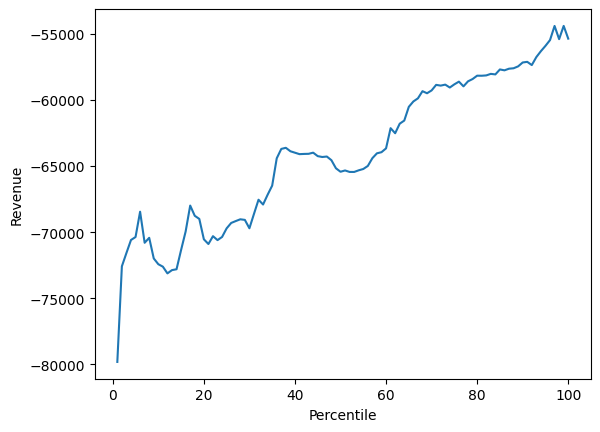

In [197]:
curve, P = revenue_curve(3, 4.0)

import matplotlib.pyplot as plt

plt.plot(P, curve)
plt.xlabel("Percentile")
plt.ylabel("Revenue")
plt.show()

15. Compare reconstructed vs actual curve and compute error

In [ ]:
import matplotlib.pyplot as plt

scenario = 3
bess_h = 4.0

pred_curve, P = revenue_curve(scenario, bess_h)
actual_curve = curve_df.loc[(scenario, bess_h), P].to_numpy()

residual = pred_curve - actual_curve

error_df = pd.DataFrame({
    "percentile": P,
    "actual_revenue": actual_curve,
    "predicted_revenue": pred_curve,
    "error": residual,
    "abs_error": np.abs(residual),
})

mae = error_df["abs_error"].mean()
rmse = np.sqrt((error_df["error"] ** 2).mean())
max_abs_error = error_df["abs_error"].max()

print(f"Scenario={scenario}, BESS={bess_h}h")
print(f"MAE: {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"Max |error|: {max_abs_error:,.2f}")

display(error_df.head(10))

plt.figure(figsize=(10, 5))
plt.plot(P, actual_curve, label="Actual", linewidth=2)
plt.plot(P, pred_curve, label="Reconstructed", linewidth=2, linestyle="--")
plt.xlabel("Percentile")
plt.ylabel("Revenue")
plt.title(f"Actual vs Reconstructed Revenue Curve (scenario={scenario}, BESS={bess_h}h)")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 3.5))
plt.plot(P, residual, label="Error (pred - actual)")
plt.axhline(0, color="black", linewidth=1)
plt.xlabel("Percentile")
plt.ylabel("Error")
plt.title("Reconstruction Error by Percentile")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()